# Game Recommendation System — EDA + Modelos

**Abordagens:** Content-Based (TF-IDF) e Collaborative Filtering (user-item matrix)  
**Dataset:** Steam Store Games — Kaggle (27k jogos)  
**Métricas:** precision@k, recall@k

In [3]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Carregamento dos dados

In [4]:
from utils import load_steam_data

DATA_DIR = os.path.join('..', 'data')
df = load_steam_data(DATA_DIR)

# Colunas derivadas criadas aqui pra estarem disponíveis em todas as células
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
df['approval']      = df['positive_ratings'] / df['total_ratings'].replace(0, np.nan)
df['year']          = pd.to_datetime(df['release_date'], errors='coerce').dt.year

print(f'Shape: {df.shape}')
df.head()

Shape: (27033, 23)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,negative_ratings,average_playtime,median_playtime,owners,price,short_description,rating,total_ratings,approval,year
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player Online Multi-Player Local Multi-P...,Action,...,3339,17612,317,10000000-20000000,7.19,Play the world's number 1 online action game. ...,4.90,127873,0.973888,2000
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player Online Multi-Player Local Multi-P...,Action,...,633,277,62,5000000-10000000,3.99,One of the most popular online action games of...,4.36,3951,0.839787,1999
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player Valve Anti-Cheat enabled,Action,...,398,187,34,5000000-10000000,3.99,Enlist in an intense brand of Axis vs. Allied ...,4.58,3814,0.895648,2003
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player Online Multi-Player Local Multi-P...,Action,...,267,258,184,5000000-10000000,3.99,Enjoy fast-paced multiplayer gaming with Death...,4.31,1540,0.826623,2001
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player Multi-player Valve Anti-Cheat en...,Action,...,288,624,415,5000000-10000000,3.99,Return to the Black Mesa Research Facility as ...,4.79,5538,0.947996,1999


## 2. EDA — Exploratory Data Analysis

In [5]:
print('Valores ausentes:')
print(df.isnull().sum())
print()
print('Tipos de dados:')
print(df.dtypes)

Valores ausentes:
appid                 0
name                  0
release_date          0
english               0
developer             1
publisher            14
platforms             0
required_age          0
categories            0
genres                0
steamspy_tags         0
achievements          0
positive_ratings      0
negative_ratings      0
average_playtime      0
median_playtime       0
owners                0
price                 0
short_description     0
rating                0
total_ratings         0
approval              0
year                  0
dtype: int64

Tipos de dados:
appid                  int64
name                     str
release_date             str
english                int64
developer                str
publisher                str
platforms                str
required_age           int64
categories               str
genres                   str
steamspy_tags            str
achievements           int64
positive_ratings       int64
negative_ratings       

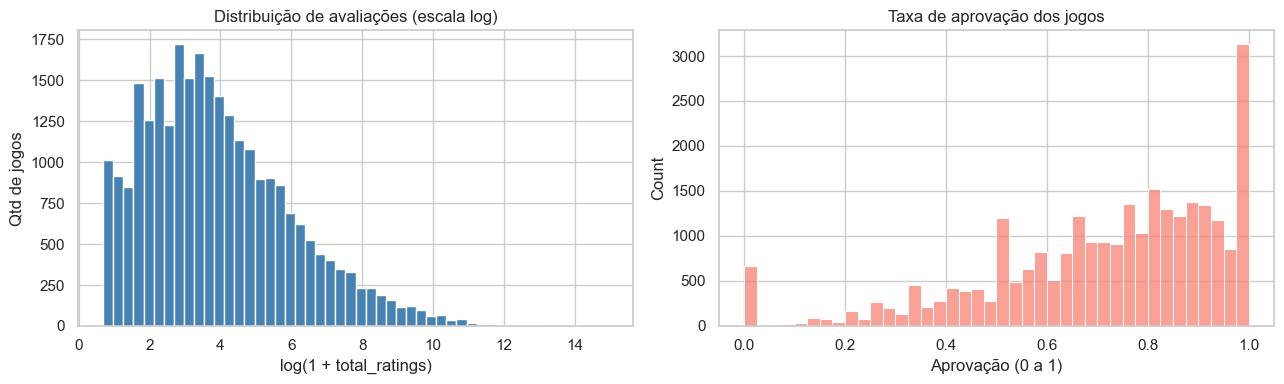

Jogos com < 10 avaliações:  24.2%
Jogos com < 100 avaliações: 67.6%
Top 1% dos jogos concentra 63.8% de todos os votos


In [6]:
# Distribuição de avaliações — escala log porque na linear fica impossível ver
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log1p(df['total_ratings']), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de avaliações (escala log)')
axes[0].set_xlabel('log(1 + total_ratings)')
axes[0].set_ylabel('Qtd de jogos')

sns.histplot(df['approval'].dropna(), bins=40, ax=axes[1], color='salmon')
axes[1].set_title('Taxa de aprovação dos jogos')
axes[1].set_xlabel('Aprovação (0 a 1)')

plt.tight_layout()
plt.show()

pct_menos10  = (df['total_ratings'] < 10).mean()  * 100
pct_menos100 = (df['total_ratings'] < 100).mean() * 100
top1pct_share = df.nlargest(int(len(df)*0.01), 'total_ratings')['total_ratings'].sum() / df['total_ratings'].sum() * 100

print(f'Jogos com < 10 avaliações:  {pct_menos10:.1f}%')
print(f'Jogos com < 100 avaliações: {pct_menos100:.1f}%')
print(f'Top 1% dos jogos concentra {top1pct_share:.1f}% de todos os votos')

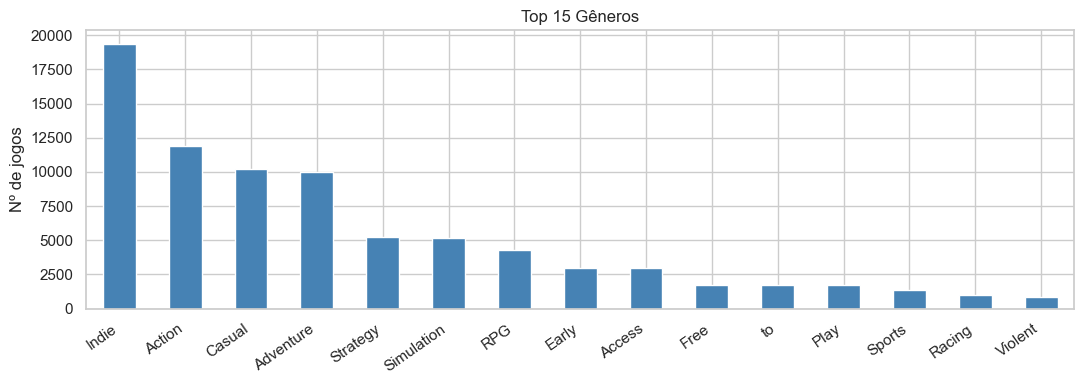

genres
Indie         19392
Action        11884
Casual        10190
Adventure     10017
Strategy       5243
Simulation     5180
RPG            4304
Early          2949
Access         2949
Free           1702
to             1702
Play           1702
Sports         1321
Racing         1022
Violent         843
Name: count, dtype: int64


In [7]:
# Gêneros — Indie domina completamente o catálogo
# O separador já foi normalizado para espaço pelo load_steam_data
genre_series = df['genres'].dropna().str.split(' ').explode().str.strip()
genre_series = genre_series[genre_series.str.len() > 1]  # remove tokens vazios
top_genres = genre_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 4))
top_genres.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Gêneros')
ax.set_xlabel('')
ax.set_ylabel('Nº de jogos')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print(top_genres)

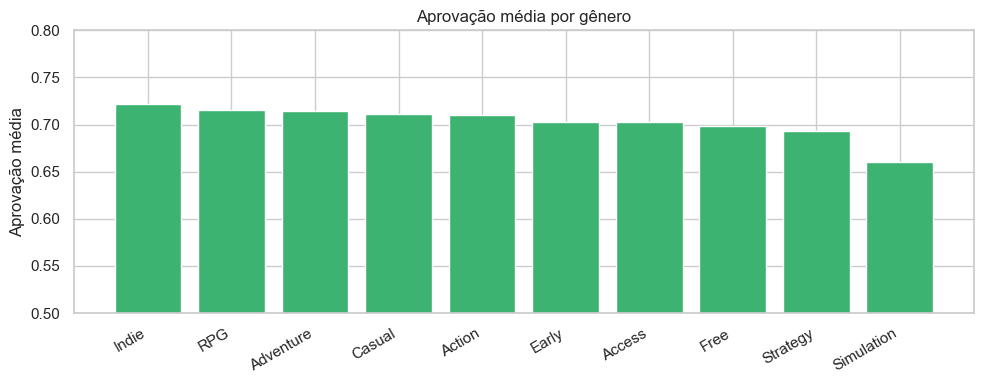

    genero  qtd_jogos  aprovacao_media
     Indie      19392            0.722
       RPG       4304            0.716
 Adventure      10017            0.714
    Casual      10190            0.711
    Action      11884            0.710
     Early       2949            0.703
    Access       2949            0.703
      Free       1702            0.699
  Strategy       5243            0.693
Simulation       5180            0.660


In [8]:
# Aprovação média por gênero
# Simulation e Sports ficam abaixo dos outros — provavelmente expectativa técnica
# mais alta (física, IA) que jogos menores não conseguem entregar
top10_genres = genre_series.value_counts().head(10).index.tolist()
genre_approval = []

for g in top10_genres:
    mask = df['genres'].fillna('').str.contains(g)
    genre_approval.append({
        'genero': g,
        'qtd_jogos': int(mask.sum()),
        'aprovacao_media': round(float(df.loc[mask, 'approval'].mean()), 3)
    })

ga_df = pd.DataFrame(genre_approval).sort_values('aprovacao_media', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ga_df['genero'], ga_df['aprovacao_media'], color='mediumseagreen', edgecolor='white')
ax.set_ylim(0.5, 0.8)
ax.set_title('Aprovação média por gênero')
ax.set_ylabel('Aprovação média')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(ga_df.to_string(index=False))

In [9]:
# Top 10 mais avaliados e casos extremos
print('Top 10 jogos mais avaliados:')
print(df.nlargest(10, 'total_ratings')[['name', 'positive_ratings', 'negative_ratings', 'total_ratings']].to_string(index=False))

print('\nTop 5 mais aprovados (mínimo 1.000 votos):')
popular = df[df['total_ratings'] >= 1000]
print(popular.nlargest(5, 'approval')[['name', 'total_ratings', 'approval']].to_string(index=False))

print('\nTop 5 menos aprovados (mínimo 1.000 votos):')
print(popular.nsmallest(5, 'approval')[['name', 'total_ratings', 'approval']].to_string(index=False))
# Os piores são quase todos decepções de franquias (C&C4, Flatout 3, RCT World) —
# o dataset captura muito bem esse tipo de rejeição da comunidade

Top 10 jogos mais avaliados:
                            name  positive_ratings  negative_ratings  total_ratings
Counter-Strike: Global Offensive           2644404            402313        3046717
                          Dota 2            863507            142079        1005586
   PLAYERUNKNOWN'S BATTLEGROUNDS            496184            487076         983260
                 Team Fortress 2            515879             34036         549915
              Grand Theft Auto V            329061            139308         468369
                     Garry's Mod            363721             16433         380154
                        PAYDAY 2            308657             56523         365180
                        Unturned            292574             31482         324056
 Tom Clancy's Rainbow Six® Siege            251178             59620         310798
                            Rust            220370             53709         274079

Top 5 mais aprovados (mínimo 1.000 votos):
   

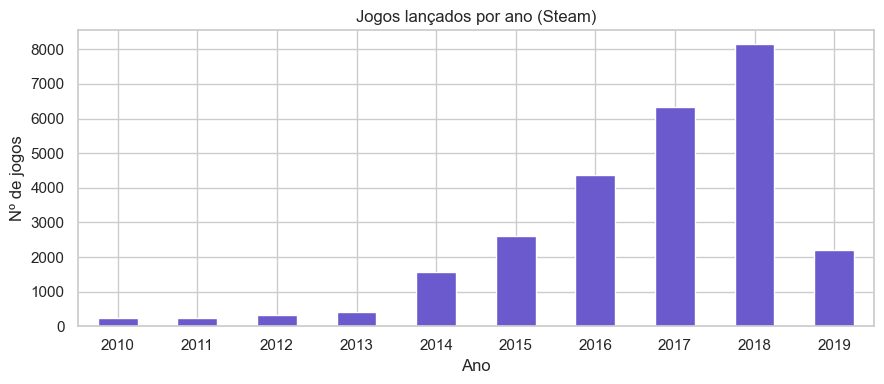

year
2010     238
2011     239
2012     320
2013     418
2014    1555
2015    2596
2016    4358
2017    6346
2018    8138
2019    2208
Name: count, dtype: int64


In [10]:
# Crescimento do catálogo por ano
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
yearly = df[df['year'].between(2010, 2019)]['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
yearly.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Jogos lançados por ano (Steam)')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de jogos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(yearly)

In [11]:
# average_playtime está zerado pra maioria dos jogos — descartado como feature
zero_playtime = (df['average_playtime'] == 0).mean() * 100
print(f'Jogos com average_playtime == 0: {zero_playtime:.1f}%')
print('→ Coluna inutilizável como feature. Seria necessária a Steam Web API para playtime por usuário.')

Jogos com average_playtime == 0: 77.2%
→ Coluna inutilizável como feature. Seria necessária a Steam Web API para playtime por usuário.


## 3. Content-Based Filtering

In [12]:
from content_based import build_tfidf_matrix, get_recommendations as cb_recommend

tfidf_matrix, vectorizer = build_tfidf_matrix(df)
print(f'Matriz TF-IDF: {tfidf_matrix.shape}')

Matriz TF-IDF: (27033, 10000)


In [13]:
# Testando com Counter-Strike — FPS multiplayer competitivo deveria aparecer no topo
recs_cb = cb_recommend('Counter-Strike', df, tfidf_matrix, top_n=10)
print("Recomendações para 'Counter-Strike':")
recs_cb

Recomendações para 'Counter-Strike':


,name,genres,steamspy_tags,similarity_score
0,Operation swat,Violent Action Strategy,Action Violent Strategy,0.2471
1,Scrunk,Action Indie,Action Indie Multiplayer,0.2329
2,Astroe,Action Indie,Action Indie,0.2219
3,Team Fortress Classic,Action,Action FPS Multiplayer,0.2211
4,Freefall Tournament,Action,Action PvP Team-Based,0.2181
5,BLACK CLOVER: QUARTET KNIGHTS,Action,Action Anime Fighting,0.1995
6,Smashbox Arena,Action Indie,VR Shooter Multiplayer,0.1939
7,Hero Battle,Action Massively Multiplayer,Massively Multiplayer Action,0.1865
8,Microgons,Strategy,Strategy Turn-Based Multiplayer,0.1855
9,H-Hour: World's Elite,Action Indie Early Access,Early Access Action Indie,0.1816


In [14]:
# Testando com um RPG
recs_rpg = cb_recommend('The Elder Scrolls V: Skyrim', df, tfidf_matrix, top_n=5)
print("Recomendações para 'Skyrim':")
recs_rpg

Recomendações para 'Skyrim':


,name,genres,steamspy_tags,similarity_score
0,The Elder Scrolls V: Skyrim VR,RPG,RPG Open World Singleplayer,0.4386
1,Fallout 4,RPG,Open World Post-apocalyptic Exploration,0.4030
2,The Elder Scrolls III: Morrowind® Game of the ...,RPG,RPG Open World Fantasy,0.3260
3,Avadon: The Black Fortress,RPG Indie,RPG Indie Fantasy,0.3217
4,Survival: Last Day,Action Adventure Indie RPG,Survival Multiplayer Open World,0.2792


## 4. Collaborative Filtering

In [15]:
from collaborative import (
    build_interactions_from_steam,
    build_user_item_matrix,
    get_recommendations as cf_recommend,
    user_train_test_split,
    evaluate
)

interactions = build_interactions_from_steam(df, n_users=300)
print(f'Interações geradas: {len(interactions)} para {interactions["user_id"].nunique()} usuários')
interactions.head()

Interações geradas: 6131 para 300 usuários


,user_id,game_name,rating
0,User_0,8 Queens,2.8
1,User_0,CopperCube 5 Game Engine,3.7
2,User_0,英语杀,2.7
3,User_0,Way of the Red,4.9
4,User_0,PD Howler 9.6 Digital Painter and Visual FX box,3.9


In [16]:
# Split por usuário — 25% dos jogos de cada usuário vão pro teste
train_df, test_df = user_train_test_split(interactions, test_ratio=0.25)
train_matrix = build_user_item_matrix(train_df)
print(f'Matriz de treino: {train_matrix.shape[0]} usuários × {train_matrix.shape[1]} jogos')

Matriz de treino: 300 usuários × 3525 jogos


In [17]:
recs_cf = cf_recommend('User_0', train_matrix, top_n=10)
print("Recomendações para 'User_0':")
recs_cf

Recomendações para 'User_0':


,game_name,predicted_rating
0,3DCoat 4.8,5.0
1,GameMaker Studio 2 UWP,5.0
2,Wandering Willows™,5.0
3,ItzaZoo,5.0
4,Nekomew's Potty Trouble,5.0
5,アルカナリッター,5.0
6,Escape Goat,5.0
7,Wing IDE 5,5.0
8,The Astonishing Game,5.0
9,Renegade Tabletop Tools System,5.0


## 5. Avaliação e comparação dos modelos

In [18]:
metrics_cf = evaluate(train_matrix, test_df, k=10)
print('=== Collaborative Filtering ===')
for m, v in metrics_cf.items():
    print(f'  {m}: {v}')

=== Collaborative Filtering ===
  precision@10: 0.0033
  recall@10: 0.0065


In [19]:
from utils import precision_at_k, recall_at_k

# Content-based: relevância = compartilhar ao menos um gênero com o jogo de entrada
rng = np.random.default_rng(42)
cb_precisions, cb_recalls = [], []

sample_games = df[df['total_ratings'] >= 100]['name'].sample(100, random_state=42)

for game in sample_games:
    try:
        rec = cb_recommend(game, df, tfidf_matrix, top_n=10)
        ref_genre = df[df['name'] == game]['genres'].iloc[0]
        # jogos que compartilham ao menos uma tag de gênero
        ref_tokens = set(str(ref_genre).split())
        relevant = df[df['genres'].apply(
            lambda g: bool(set(str(g).split()) & ref_tokens)
        )]['name'].tolist()
        cb_precisions.append(precision_at_k(rec['name'].tolist(), relevant, 10))
        cb_recalls.append(recall_at_k(rec['name'].tolist(), relevant, 10))
    except Exception:
        continue

print(f'=== Content-Based ===')
print(f'  precision@10: {np.mean(cb_precisions):.4f}')
print(f'  recall@10:    {np.mean(cb_recalls):.4f}')

=== Content-Based ===
  precision@10: 0.9480
  recall@10:    0.0006



=== Comparação dos Modelos ===
                  Model  Precision@10  Recall@10
          Content-Based        0.9480     0.0006
Collaborative Filtering        0.0033     0.0065


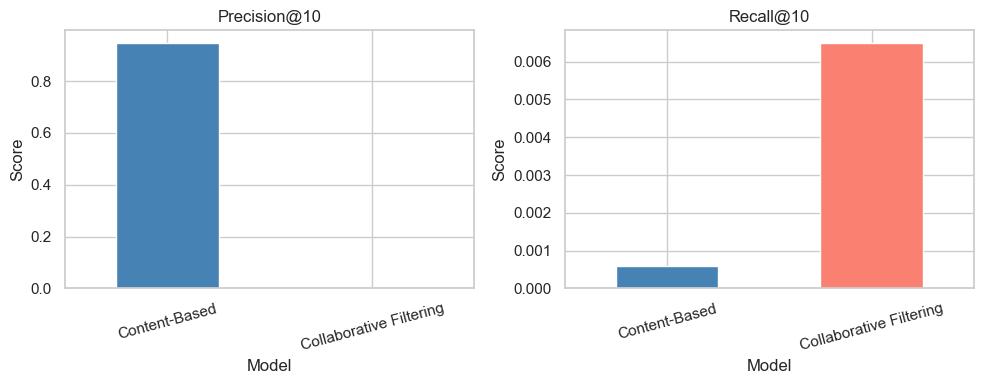

In [20]:
results = pd.DataFrame({
    'Model': ['Content-Based', 'Collaborative Filtering'],
    'Precision@10': [round(float(np.mean(cb_precisions)), 4), metrics_cf.get('precision@10', 0)],
    'Recall@10':    [round(float(np.mean(cb_recalls)), 4),    metrics_cf.get('recall@10', 0)],
})

print('\n=== Comparação dos Modelos ===')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'salmon']

results.plot(x='Model', y='Precision@10', kind='bar', ax=axes[0], legend=False, color=colors)
axes[0].set_title('Precision@10')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=15)

results.plot(x='Model', y='Recall@10', kind='bar', ax=axes[1], legend=False, color=colors)
axes[1].set_title('Recall@10')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=120)
plt.show()

In [21]:
print('=== Resumo final ===\n')
print(results.to_string(index=False))

print("""
Observações:
- Content-Based funciona bem para jogos com tags definidas. Perde em jogos de nicho
  ou com descrição genérica demais — o TF-IDF não consegue diferenciar.
- Filtragem Colaborativa com dados sintéticos tem métricas baixas por construção:
  usuários simulados são mais previsíveis que usuários reais. Com dados reais via
  Steam Web API a arquitetura seria idêntica — o gargalo é a fonte dos dados.
- Próximo passo natural: modelo híbrido combinando os dois sinais, especialmente
  útil para cold start (usuários novos sem histórico).
""")

=== Resumo final ===

                  Model  Precision@10  Recall@10
          Content-Based        0.9480     0.0006
Collaborative Filtering        0.0033     0.0065

Observações:
- Content-Based funciona bem para jogos com tags definidas. Perde em jogos de nicho
  ou com descrição genérica demais — o TF-IDF não consegue diferenciar.
- Filtragem Colaborativa com dados sintéticos tem métricas baixas por construção:
  usuários simulados são mais previsíveis que usuários reais. Com dados reais via
  Steam Web API a arquitetura seria idêntica — o gargalo é a fonte dos dados.
- Próximo passo natural: modelo híbrido combinando os dois sinais, especialmente
  útil para cold start (usuários novos sem histórico).

